# Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# Load the data


In [2]:
DATA = Path("../data/raw")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

prices = pd.read_parquet(DATA / "prices_se3_hourly.parquet")
weather = pd.read_parquet(DATA / "weather_stockholm_hourly.parquet")

prices["hour"] = prices["time_local"].dt.hour
prices["weekday"] = prices["time_local"].dt.dayofweek
prices["month"] = prices["time_local"].dt.month

print(prices.shape)
print(weather.shape)

(34247, 7)
(34224, 6)


# Check for missing hours

In [3]:
full_range = pd.date_range(prices["time_utc"].min(), prices["time_utc"].max(), freq="h")
print("missing price hours:", len(full_range) - len(prices))
print("negative price hours:", (prices["price_sek_kwh"] < 0).sum())

missing price hours: 0
negative price hours: 1508


# Price over the whole period

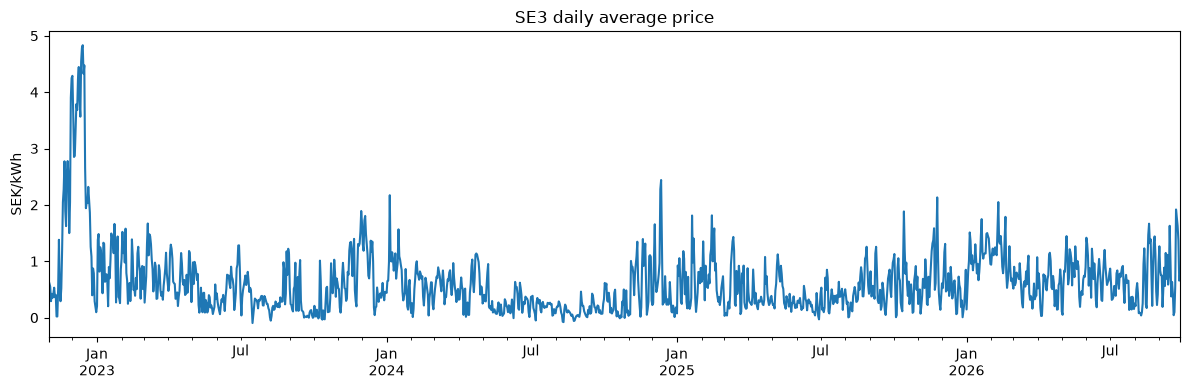

In [4]:
daily = prices.set_index("time_local")["price_sek_kwh"].resample("D").mean()

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax)
ax.set_title("SE3 daily average price")
ax.set_ylabel("SEK/kWh")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIGURES / "daily_price.png", dpi=150)
plt.show()

# For check the graph is correct

In [5]:
#print(daily.loc["2026-09-22"])
#print(daily.loc["2026-01-01":"2026-09-22"].nlargest(3))
#print(prices.set_index("time_local").loc["2022-11-12 02:00":"2022-11-12 05:00", "price_sek_kwh"])

# Price during the day, winter vs summer

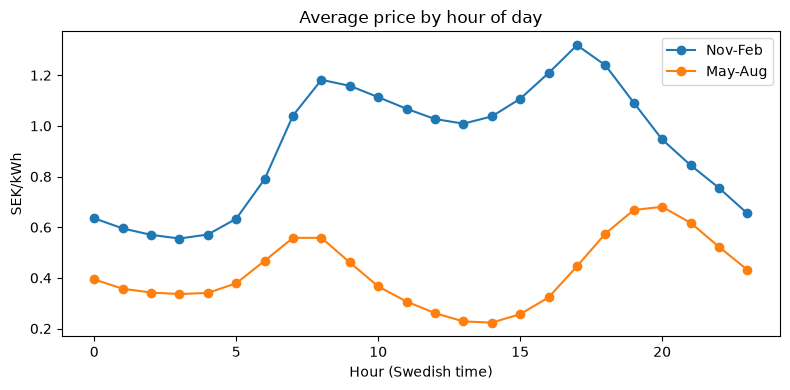

In [6]:
winter = prices[prices["month"].isin([11, 12, 1, 2])]
summer = prices[prices["month"].isin([5, 6, 7, 8])]

fig, ax = plt.subplots(figsize=(8, 4))
winter.groupby("hour")["price_sek_kwh"].mean().plot(ax=ax, label="Nov-Feb", marker="o")
summer.groupby("hour")["price_sek_kwh"].mean().plot(ax=ax, label="May-Aug", marker="o")
ax.set_title("Average price by hour of day")
ax.set_xlabel("Hour (Swedish time)")
ax.set_ylabel("SEK/kWh")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "hourly_profile.png", dpi=150)
plt.show()

# For check the graph is correct

In [7]:
print(winter.groupby("hour").size().unique())
print(summer.groupby("hour").size().unique())

[481]
[492]


# Price by weekday

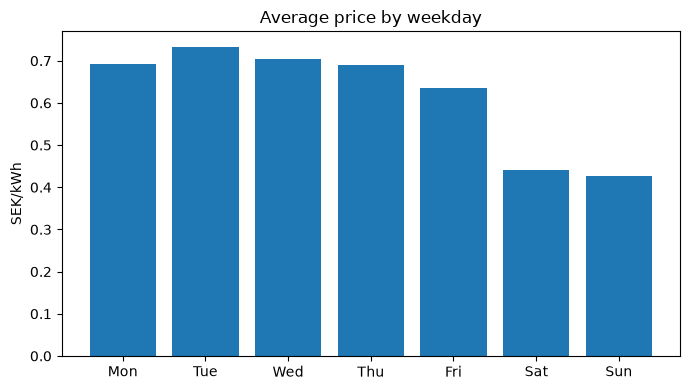

In [8]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_day = prices.groupby("weekday")["price_sek_kwh"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(days, by_day.values)
ax.set_title("Average price by weekday")
ax.set_ylabel("SEK/kWh")
fig.tight_layout()
fig.savefig(FIGURES / "weekday_profile.png", dpi=150)
plt.show()

In [9]:
#print(prices.groupby("weekday").size())

# Price by month

In [18]:
%%script false --no-raise-error  #block thi whole code


by_month = prices.groupby("month")["price_sek_kwh"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_month.index, by_month.values)
ax.set_xticks(range(1, 13))
ax.set_title("Average price by month")
ax.set_xlabel("Month")
ax.set_ylabel("SEK/kWh")
fig.tight_layout()
fig.savefig(FIGURES / "monthly_profile.png", dpi=150)
plt.show()

year    2022   2023   2024   2025   2026
month                                   
1        NaN  0.926  0.802  0.635  1.085
2        NaN  0.826  0.504  0.770  1.102
3        NaN  0.807  0.595  0.509  0.587
4        NaN  0.688  0.563  0.375  0.561
5        NaN  0.392  0.237  0.430  0.770
6        NaN  0.530  0.273  0.228  0.780
7        NaN  0.377  0.207  0.370  0.536
8        NaN  0.369  0.085  0.486  0.667
9        NaN  0.243  0.164  0.523  0.850
10       NaN  0.331  0.230  0.628    NaN
11     1.309  0.822  0.669  0.697    NaN
12     2.689  0.792  0.583  0.517    NaN


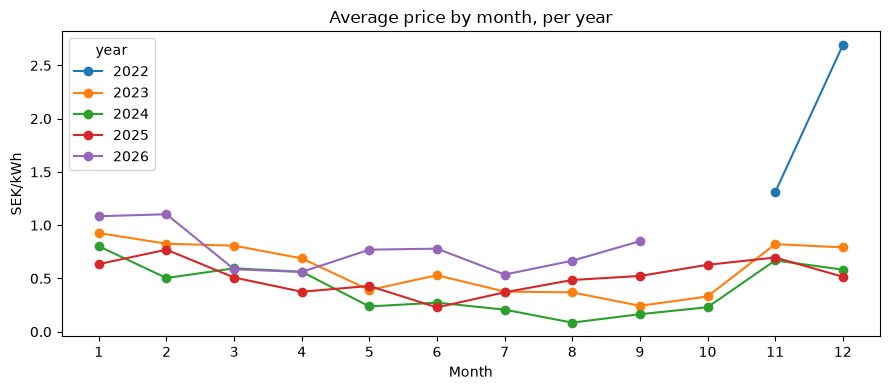

In [11]:
prices["year"] = prices["time_local"].dt.year
monthly = prices.pivot_table(index="month", columns="year", values="price_sek_kwh", aggfunc="mean")
print(monthly.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o")
ax.set_xticks(range(1, 13))
ax.set_title("Average price by month, per year")
ax.set_xlabel("Month")
ax.set_ylabel("SEK/kWh")
fig.tight_layout()
fig.savefig(FIGURES / "monthly_by_year.png", dpi=150)
plt.show()

# Price distribution

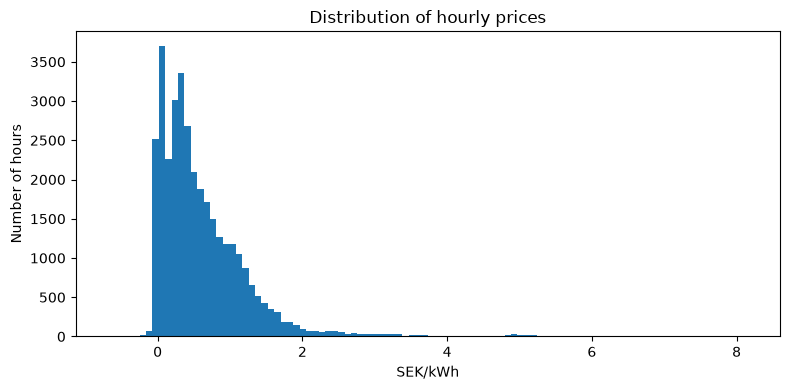

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prices["price_sek_kwh"], bins=100)
ax.set_title("Distribution of hourly prices")
ax.set_xlabel("SEK/kWh")
ax.set_ylabel("Number of hours")
fig.tight_layout()
fig.savefig(FIGURES / "price_distribution.png", dpi=150)
plt.show()

In [13]:
print(prices.loc[prices["price_sek_kwh"].idxmax(), ["time_local", "price_sek_kwh"]])
print(prices.loc[prices["price_sek_kwh"].idxmin(), ["time_local", "price_sek_kwh"]])

time_local       2024-12-12 17:00:00+01:00
price_sek_kwh                      8.15709
Name: 18545, dtype: object
time_local       2023-07-16 14:00:00+02:00
price_sek_kwh                     -0.69112
Name: 6181, dtype: object


# Price vs weather

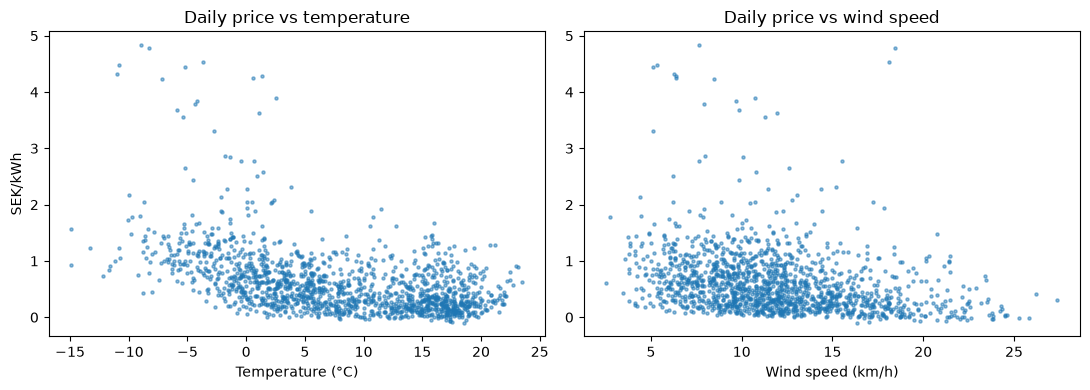

                price_sek_kwh  temperature_2m  wind_speed_10m
price_sek_kwh            1.00           -0.47           -0.28
temperature_2m          -0.47            1.00           -0.08
wind_speed_10m          -0.28           -0.08            1.00


In [14]:
df = prices.merge(weather, on="time_utc", how="inner")
daily_df = (
    df.set_index("time_local")[["price_sek_kwh", "temperature_2m", "wind_speed_10m"]]
    .resample("D")
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(daily_df["temperature_2m"], daily_df["price_sek_kwh"], s=5, alpha=0.5)
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("SEK/kWh")
axes[0].set_title("Daily price vs temperature")
axes[1].scatter(daily_df["wind_speed_10m"], daily_df["price_sek_kwh"], s=5, alpha=0.5)
axes[1].set_xlabel("Wind speed (km/h)")
axes[1].set_title("Daily price vs wind speed")
fig.tight_layout()
fig.savefig(FIGURES / "price_vs_weather.png", dpi=150)
plt.show()

print(daily_df.corr().round(2))

# How much does the past predict the future?

In [15]:
s = prices.set_index("time_utc")["price_sek_kwh"]
for lag in [1, 24, 168]:
    print(f"correlation with price {lag} hours earlier: {s.autocorr(lag):.3f}")

correlation with price 1 hours earlier: 0.969
correlation with price 24 hours earlier: 0.789
correlation with price 168 hours earlier: 0.596


In [16]:
for lag in [1, 24, 168]:
    print(lag, round(s.autocorr(lag), 3), round(s.corr(s.shift(lag, freq="h")), 3))

1 0.969 0.969
24 0.789 0.789
168 0.596 0.596
